In [2]:
from fista.lr import LogisticRegression
from sklearn.linear_model import LogisticRegression as LogisticRegressionSKL
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [ ]:
def evaluate_model(model, X, y_true, threshold=0.5):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        if len(proba.shape) == 1:
            y_proba = proba
        else:
            y_proba = proba[:, 1]
        y_pred = (y_proba >= threshold).astype(int)

    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "average_precision": average_precision_score(y_true, y_proba),
    }

    return results

In [ ]:
def sigmoid(x):
    res = np.exp(x) / (1 + np.exp(x))
    return res


def generate_data(coefs, n=1000, k=20, alpha=-1):
    l = len(coefs)
    p = l + k
    X = np.zeros((n, p))
    for j in np.arange(0, p, 1):
        X[:, j] = np.random.normal(0, 1, size=n)

    beta_true = np.zeros(p)
    beta_true[0:l] = coefs
    eta = alpha + np.dot(X, beta_true)
    prob_true = sigmoid(eta)

    y = np.zeros(n)
    for i in np.arange(0, n, 1):
        y[i] = np.random.binomial(1, prob_true[i], size=1)[0]

    return pd.DataFrame(X), pd.Series(y), beta_true

In [ ]:
def generate_data_probit(
    coefs, n=1000, k=20, alpha=0, rho=0.5, interaction_strength=1.0
):
    l = len(coefs)
    p = l + k
    cov_matrix = np.array([[rho ** abs(i - j) for j in range(p)] for i in range(p)])
    X = np.random.multivariate_normal(mean=np.zeros(p), cov=cov_matrix, size=n)

    beta_true = np.zeros(p)
    beta_true[:l] = coefs

    eta = alpha + X @ beta_true

    # Pairwise interactions among the signal features
    for i in range(l):
        for j in range(i + 1, l):
            eta += interaction_strength * X[:, i] * X[:, j]

    # Quadratic terms on signal features
    for i in range(l):
        eta += interaction_strength * 0.5 * X[:, i] ** 2

    prob_true = norm.cdf(eta)
    y = np.random.binomial(1, prob_true)

    return pd.DataFrame(X), pd.Series(y), beta_true

In [ ]:
coefs = np.zeros(17)
coefs[0:4] = np.random.normal(1, 1, size=4)
coefs[4:8] = np.random.normal(-2, 1, size=4)
coefs[8:12] = 3
coefs[12:17] = np.random.normal(7, 1, size=5)

## Beta Comparison

### logistic model

In [ ]:
X, y, beta_true = generate_data(coefs, n=5000, k=20, alpha=-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=7
)

lr1 = LogisticRegression(lmbd=2, max_iter=1000, tol=1e-5)
lr2 = LogisticRegressionSKL(
    l1_ratio=1, C=1, max_iter=1000, solver="liblinear", tol=1e-5
)
lr3 = LogisticRegressionSKL(l1_ratio=1, C=1, max_iter=1000, solver="saga", tol=1e-5)
lr1.fit(X_train, y_train)
lr2.fit(X_train, y_train)
lr3.fit(X_train, y_train)

models = {"fista": lr1, "liblinear": lr2, "saga": lr3}

results = {}

for name, model in models.items():
    results[name] = evaluate_model(model, X_test, y_test)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


fista:
  accuracy: 0.9640
  recall: 0.9633
  precision: 0.9606
  f1: 0.9619
  balanced_accuracy: 0.9640
  roc_auc: 0.9964
  average_precision: 0.9961

liblinear:
  accuracy: 0.9640
  recall: 0.9633
  precision: 0.9606
  f1: 0.9619
  balanced_accuracy: 0.9640
  roc_auc: 0.9964
  average_precision: 0.9961

saga:
  accuracy: 0.9640
  recall: 0.9633
  precision: 0.9606
  f1: 0.9619
  balanced_accuracy: 0.9640
  roc_auc: 0.9964
  average_precision: 0.9961


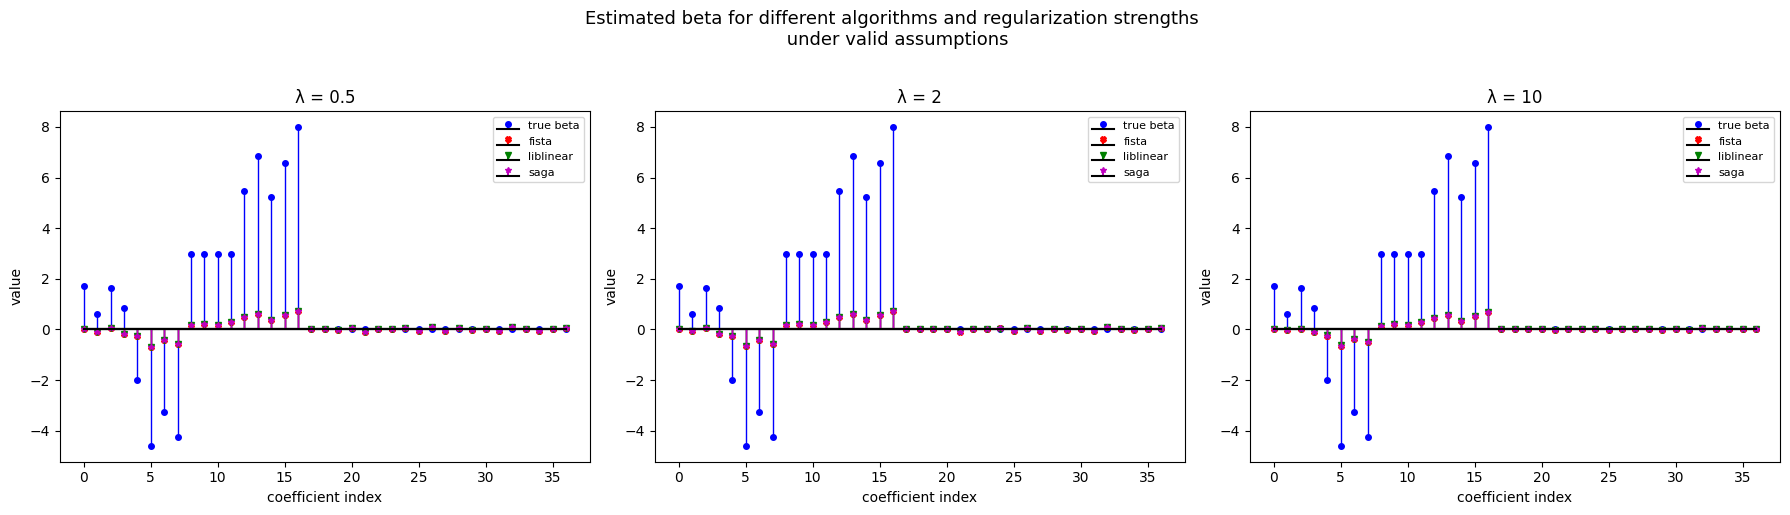

In [ ]:
lambdas = [0.5, 2, 10]
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

for idx, lmbd in enumerate(lambdas):
    C = 1 / lmbd

    lr1 = LogisticRegression(lmbd=lmbd, max_iter=1000, tol=1e-5)
    lr2 = LogisticRegressionSKL(
        l1_ratio=1, C=C, max_iter=1000, solver="liblinear", tol=1e-5
    )
    lr3 = LogisticRegressionSKL(l1_ratio=1, C=C, max_iter=1000, solver="saga", tol=1e-5)

    lr1.fit(X_train, y_train)
    lr2.fit(X_train, y_train)
    lr3.fit(X_train, y_train)

    ax = fig.add_subplot(gs[idx])

    markerline, stemlines, baseline = ax.stem(
        beta_true, linefmt="b-", markerfmt="bo", basefmt="k-", label="true beta"
    )
    plt.setp(stemlines, linewidth=1)
    plt.setp(markerline, markersize=4)

    markerline, stemlines, baseline = ax.stem(
        lr1.beta, linefmt="r-", markerfmt="rX", basefmt="k-", label="fista"
    )
    plt.setp(stemlines, linewidth=1)
    plt.setp(markerline, markersize=4)

    markerline, stemlines, baseline = ax.stem(
        lr2.coef_[0], linefmt="g-", markerfmt="gv", basefmt="k-", label="liblinear"
    )
    plt.setp(stemlines, linewidth=1)
    plt.setp(markerline, markersize=4)

    markerline, stemlines, baseline = ax.stem(
        lr3.coef_[0], linefmt="m-", markerfmt="m*", basefmt="k-", label="saga"
    )
    plt.setp(stemlines, linewidth=1)
    plt.setp(markerline, markersize=4)

    ax.set_xlabel("coefficient index")
    ax.set_ylabel("value")
    ax.set_title(f"λ = {lmbd}")
    ax.legend(fontsize=8)

fig.suptitle(
    "Estimated beta for different algorithms and regularization strengths \n under valid assumptions",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

### non logistic model

In [ ]:
X, y, beta_true = generate_data_probit(coefs, n=5000, k=20, alpha=-1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=7
)

lr1 = LogisticRegression(lmbd=2, max_iter=1000, tol=1e-5)
lr2 = LogisticRegressionSKL(
    l1_ratio=1, C=0.5, max_iter=1000, solver="liblinear", tol=1e-5
)
lr3 = LogisticRegressionSKL(l1_ratio=1, C=0.5, max_iter=1000, solver="saga", tol=1e-5)
lr1.fit(X_train, y_train)
lr2.fit(X_train, y_train)
lr3.fit(X_train, y_train)

models = {"fista": lr1, "liblinear": lr2, "saga": lr3}

results = {}

for name, model in models.items():
    results[name] = evaluate_model(model, X_test, y_test)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


fista:
  accuracy: 0.8287
  recall: 0.9031
  precision: 0.8578
  f1: 0.8799
  balanced_accuracy: 0.7812
  roc_auc: 0.9227
  average_precision: 0.9698

liblinear:
  accuracy: 0.8293
  recall: 0.9031
  precision: 0.8586
  f1: 0.8803
  balanced_accuracy: 0.7823
  roc_auc: 0.9227
  average_precision: 0.9698

saga:
  accuracy: 0.8287
  recall: 0.9031
  precision: 0.8578
  f1: 0.8799
  balanced_accuracy: 0.7812
  roc_auc: 0.9227
  average_precision: 0.9698


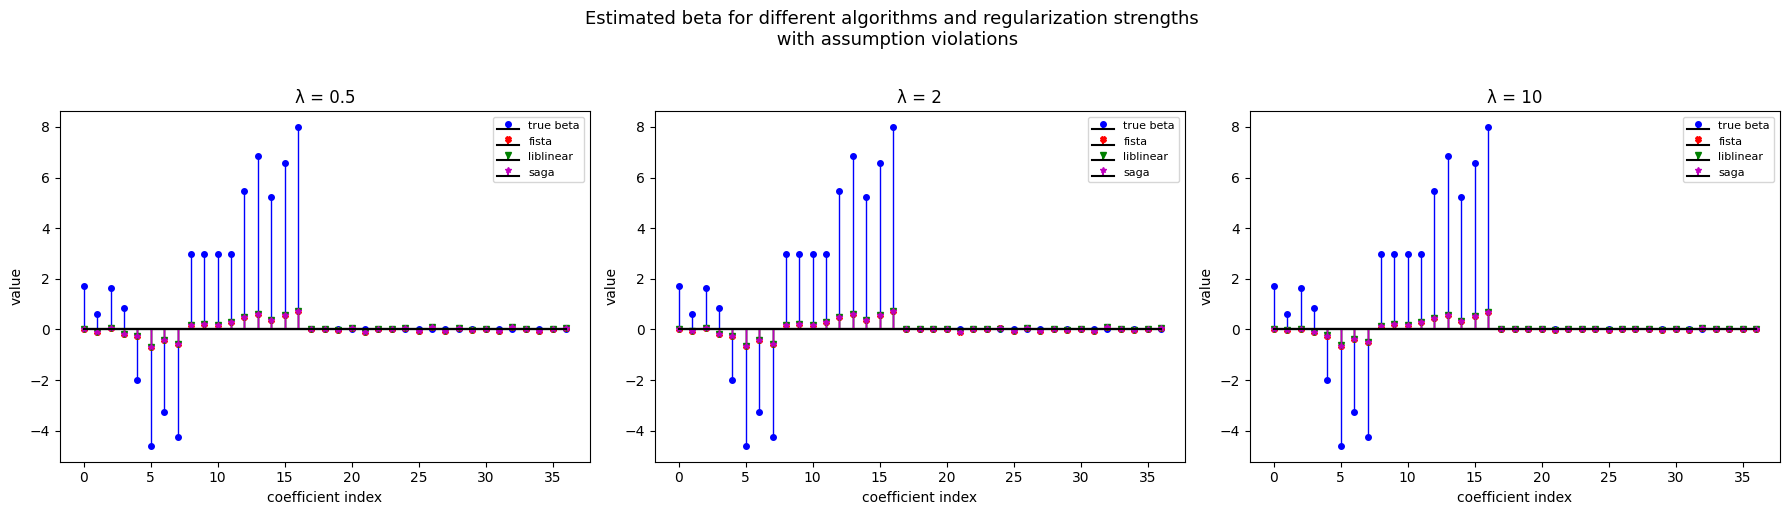

In [ ]:
lambdas = [0.5, 2, 10]
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

for idx, lmbd in enumerate(lambdas):
    C = 1 / lmbd

    lr1 = LogisticRegression(lmbd=lmbd, max_iter=1000, tol=1e-5)
    lr2 = LogisticRegressionSKL(
        l1_ratio=1, C=C, max_iter=1000, solver="liblinear", tol=1e-5
    )
    lr3 = LogisticRegressionSKL(l1_ratio=1, C=C, max_iter=1000, solver="saga", tol=1e-5)

    lr1.fit(X_train, y_train)
    lr2.fit(X_train, y_train)
    lr3.fit(X_train, y_train)

    ax = fig.add_subplot(gs[idx])

    markerline, stemlines, baseline = ax.stem(
        beta_true, linefmt="b-", markerfmt="bo", basefmt="k-", label="true beta"
    )
    plt.setp(stemlines, linewidth=1)
    plt.setp(markerline, markersize=4)

    markerline, stemlines, baseline = ax.stem(
        lr1.beta, linefmt="r-", markerfmt="rX", basefmt="k-", label="fista"
    )
    plt.setp(stemlines, linewidth=1)
    plt.setp(markerline, markersize=4)

    markerline, stemlines, baseline = ax.stem(
        lr2.coef_[0], linefmt="g-", markerfmt="gv", basefmt="k-", label="liblinear"
    )
    plt.setp(stemlines, linewidth=1)
    plt.setp(markerline, markersize=4)

    markerline, stemlines, baseline = ax.stem(
        lr3.coef_[0], linefmt="m-", markerfmt="m*", basefmt="k-", label="saga"
    )
    plt.setp(stemlines, linewidth=1)
    plt.setp(markerline, markersize=4)

    ax.set_xlabel("coefficient index")
    ax.set_ylabel("value")
    ax.set_title(f"λ = {lmbd}")
    ax.legend(fontsize=8)

fig.suptitle(
    "Estimated beta for different algorithms and regularization strengths \n with assumption violations",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()

## Convergence

### logistic model

In [ ]:
results = []
for i in range(100):
    X, y, beta_true = generate_data(coefs, n=5000, k=20, alpha=-1)
    lr = LogisticRegression(lmbd=2, max_iter=1000, tol=0)
    lr.fit(X, y, beta_true)
    results.append(lr.convergence_history)

objective = np.array([run["objective"] for run in results])
beta_error = np.array([run["beta_error"] for run in results])
obj_mean = objective.mean(axis=0)
obj_std = objective.std(axis=0)

R = objective.shape[0]
beta_mean = beta_error.mean(axis=0)
obj_std = objective.std(axis=0)
obj_se = obj_std / np.sqrt(R)
z = 1.96  # for 95% CI

obj_lower = obj_mean - z * obj_se
obj_upper = obj_mean + z * obj_se
beta_mean = beta_error.mean(axis=0)
beta_std = beta_error.std(axis=0)
beta_se = beta_std / np.sqrt(R)

beta_lower = beta_mean - z * beta_se
beta_upper = beta_mean + z * beta_se

/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/am

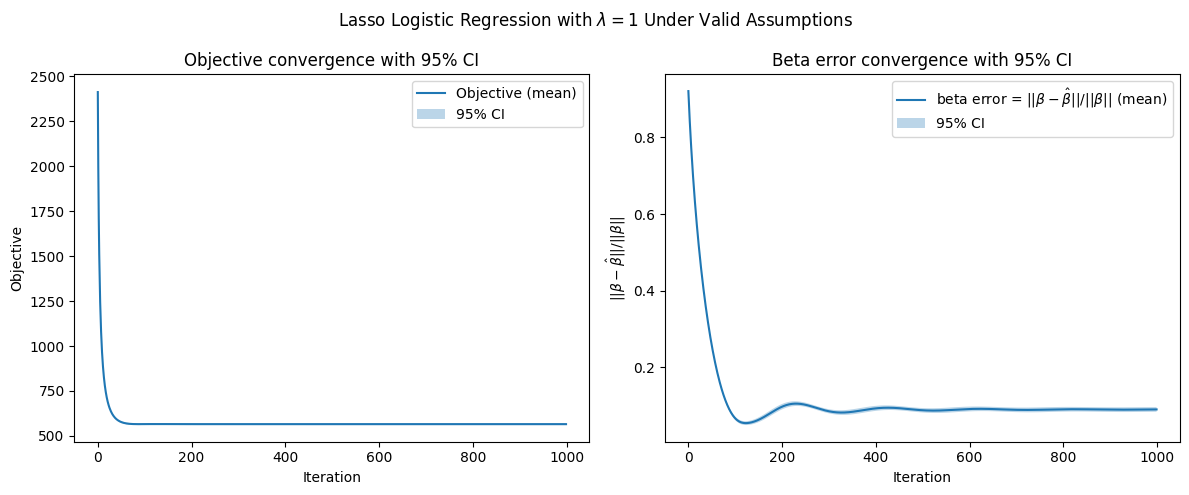

In [ ]:
k = np.arange(1, 1001)
ref = 1 / (k**2)
iterations = np.arange(objective.shape[1])
ref_scaled = ref + obj_mean[-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

axes[0].plot(iterations, obj_mean, label="Objective (mean)")
axes[0].fill_between(iterations, obj_lower, obj_upper, alpha=0.3, label="95% CI")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Objective")
axes[0].set_title("Objective convergence with 95% CI")
axes[0].legend()

axes[1].plot(
    iterations,
    beta_mean,
    label=r"beta error = $||\beta - \hat{\beta}||/||\beta||$ (mean)",
)
axes[1].fill_between(iterations, beta_lower, beta_upper, alpha=0.3, label="95% CI")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(r"$||\beta - \hat{\beta}||/||\beta||$")
axes[1].set_title("Beta error convergence with 95% CI")
axes[1].legend()
fig.suptitle(r"Lasso Logistic Regression with $\lambda=1$ Under Valid Assumptions")
plt.tight_layout()
plt.show()

### non logistic model

In [ ]:
results = []
for i in range(100):
    X, y, beta_true = generate_data_probit(coefs, n=5000, k=20, alpha=-1)
    lr = LogisticRegression(lmbd=2, max_iter=1000, tol=0)
    lr.fit(X, y, beta_true)
    results.append(lr.convergence_history)

objective = np.array([run["objective"] for run in results])
beta_error = np.array([run["beta_error"] for run in results])
obj_mean = objective.mean(axis=0)
obj_std = objective.std(axis=0)

R = objective.shape[0]
beta_mean = beta_error.mean(axis=0)
obj_std = objective.std(axis=0)
obj_se = obj_std / np.sqrt(R)
z = 1.96  # for 95% CI

obj_lower = obj_mean - z * obj_se
obj_upper = obj_mean + z * obj_se
beta_mean = beta_error.mean(axis=0)
beta_std = beta_error.std(axis=0)
beta_se = beta_std / np.sqrt(R)

beta_lower = beta_mean - z * beta_se
beta_upper = beta_mean + z * beta_se

/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/aml-project-1/src/fista/lr.py:191: RuntimeWarning: For lambda = 1, max_iter = 1000 and tol = 0 the algorithm did not converge
  warnings.warn(
/Users/ola/projects/am

In [ ]:
k = np.arange(1, 1001)
ref = 1 / (k**2)
iterations = np.arange(objective.shape[1])
ref_scaled = ref + obj_mean[-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

axes[0].plot(iterations, obj_mean, label="Objective (mean)")
axes[0].fill_between(iterations, obj_lower, obj_upper, alpha=0.3, label="95% CI")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Objective")
axes[0].set_title("Objective convergence with 95% CI")
axes[0].legend()
axes[0].yscale("log")
axes[1].plot(
    iterations,
    beta_mean,
    label=r"beta error = $||\beta - \hat{\beta}||/||\beta||$ (mean)",
)
axes[1].fill_between(iterations, beta_lower, beta_upper, alpha=0.3, label="95% CI")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(r"$||\beta - \hat{\beta}||/||\beta||$")
axes[1].set_title("Beta error convergence with 95% CI")
axes[1].legend()
fig.suptitle(r"Lasso Logistic Regression with $\lambda=1$ with Assumption Violations")
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined